# Movie Rating Prediction

Objective: Predict movie ratings using machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("movies.csv")

print(df.head())
print(df.info())

      Genre    Director  Actor 1  Actor 2  Actor 3  Rating
0    Action  Director A  Actor X  Actor Y  Actor Z     7.1
1     Drama  Director B  Actor M  Actor N  Actor O     8.3
2    Comedy  Director C  Actor P  Actor Q  Actor R     6.4
3  Thriller  Director D  Actor S  Actor T  Actor U     7.8
4   Romance  Director E  Actor V  Actor W  Actor X     6.9
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Genre     5 non-null      str    
 1   Director  5 non-null      str    
 2   Actor 1   5 non-null      str    
 3   Actor 2   5 non-null      str    
 4   Actor 3   5 non-null      str    
 5   Rating    5 non-null      float64
dtypes: float64(1), str(5)
memory usage: 372.0 bytes
None


In [3]:
# Handle Missing Values
df.dropna(inplace=True)

# Encode Categorical Columns
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actor 1'] = le.fit_transform(df['Actor 1'])
df['Actor 2'] = le.fit_transform(df['Actor 2'])
df['Actor 3'] = le.fit_transform(df['Actor 3'])

# Select Features and Target
X = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
y = df['Rating']

In [4]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.5000000000000089
RMSE: 1.5000000000000089
R² Score: nan


C:\Users\malay\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


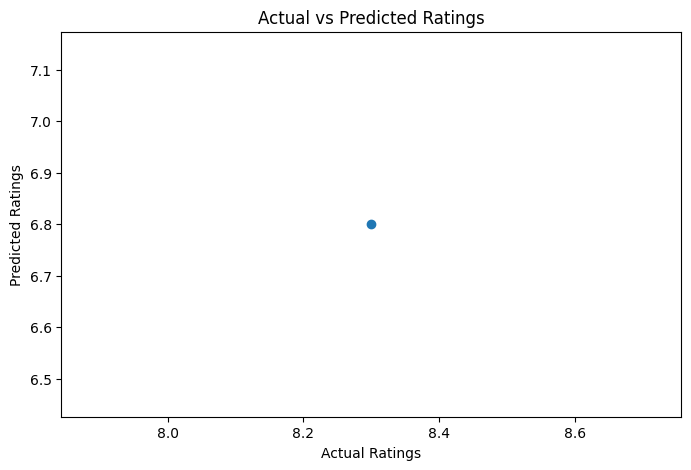

In [5]:
# Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()